## GOAL: Create a model to predict whether or not a customer will Churn .

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv('Telco-Customer-Churn.xls')

In [ ]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7032 entries, 0 to 7031
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7032 non-null   object 
 1   gender            7032 non-null   object 
 2   SeniorCitizen     7032 non-null   int64  
 3   Partner           7032 non-null   object 
 4   Dependents        7032 non-null   object 
 5   tenure            7032 non-null   int64  
 6   PhoneService      7032 non-null   object 
 7   MultipleLines     7032 non-null   object 
 8   InternetService   7032 non-null   object 
 9   OnlineSecurity    7032 non-null   object 
 10  OnlineBackup      7032 non-null   object 
 11  DeviceProtection  7032 non-null   object 
 12  TechSupport       7032 non-null   object 
 13  StreamingTV       7032 non-null   object 
 14  StreamingMovies   7032 non-null   object 
 15  Contract          7032 non-null   object 
 16  PaperlessBilling  7032 non-null   object 


In [ ]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7032.000000,7032.000000,7032.000000,7032.000000
mean,0.162400,32.421786,64.798208,2283.300441
std,0.368844,24.545260,30.085974,2266.771362
min,0.000000,1.000000,18.250000,18.800000
25%,0.000000,9.000000,35.587500,401.450000
50%,0.000000,29.000000,70.350000,1397.475000
75%,0.000000,55.000000,89.862500,3794.737500
max,1.000000,72.000000,118.750000,8684.800000


# Part 2:  Exploratory Data Analysis

## General Feature Exploration



In [ ]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


<Axes: xlabel='Churn', ylabel='count'>

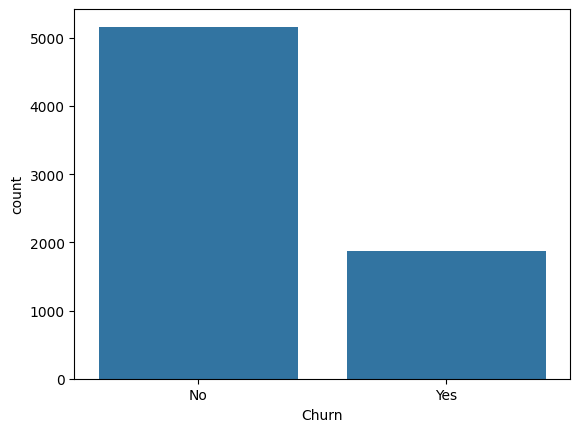

In [ ]:
sns.countplot(x='Churn',data=df)

<Axes: xlabel='TotalCharges', ylabel='Churn'>

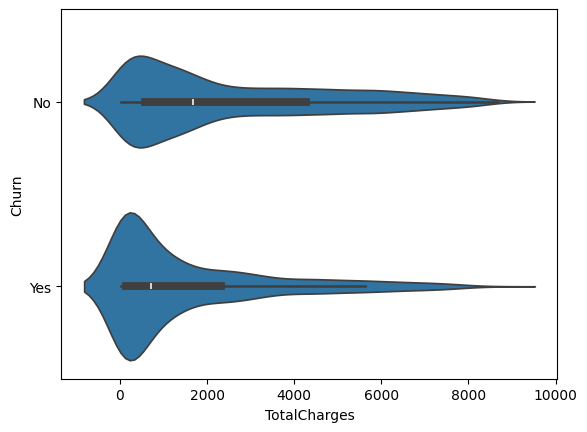

In [ ]:
sns.violinplot(x='TotalCharges',y='Churn',data=df)

<Axes: xlabel='TotalCharges', ylabel='Contract'>

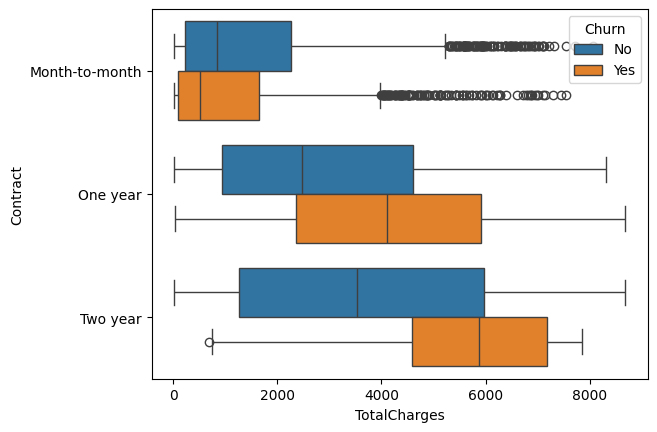

In [ ]:
sns.boxplot(data=df,x='TotalCharges',y='Contract',hue='Churn')

In [ ]:
corr=pd.get_dummies(df[['gender', 'SeniorCitizen', 'Partner', 'Dependents','PhoneService', 'MultipleLines',
 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'InternetService',
   'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod','Churn']],drop_first=True).corr()

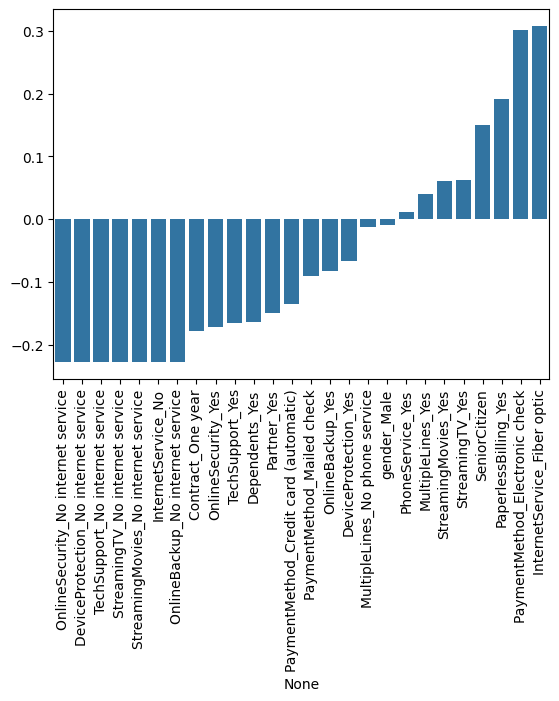

In [ ]:
abc=corr['Churn_Yes'].sort_values().iloc[1:-1]
sns.barplot(x=abc.index,y=abc.values)
plt.xticks(rotation=90);

In [ ]:
corr.corr()['Churn_Yes'][:-1].sort_values(ascending=False)

,Churn_Yes
PaymentMethod_Electronic check,0.716373
InternetService_Fiber optic,0.664889
PaperlessBilling_Yes,0.592563
SeniorCitizen,0.527401
StreamingTV_Yes,0.376897
StreamingMovies_Yes,0.373149
MultipleLines_Yes,0.319036
DeviceProtection_Yes,0.186638
OnlineBackup_Yes,0.182579
MultipleLines_No phone service,0.022611


# Part 3: Churn Analysis

**This section focuses on segementing customers based on their tenure, creating "cohorts", allowing us to examine differences between customer cohort segments.**

In [ ]:
df['Contract'].unique()

array(['Month-to-month', 'One year', 'Two year'], dtype=object)

<Axes: xlabel='tenure', ylabel='Count'>

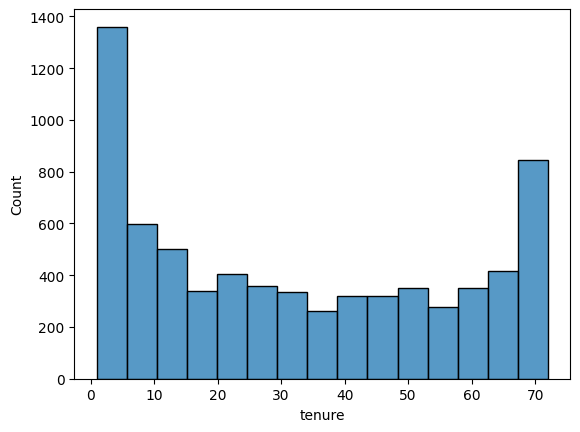

In [ ]:
sns.histplot(data=df,x='tenure')

<Axes: xlabel='Contract', ylabel='Count'>

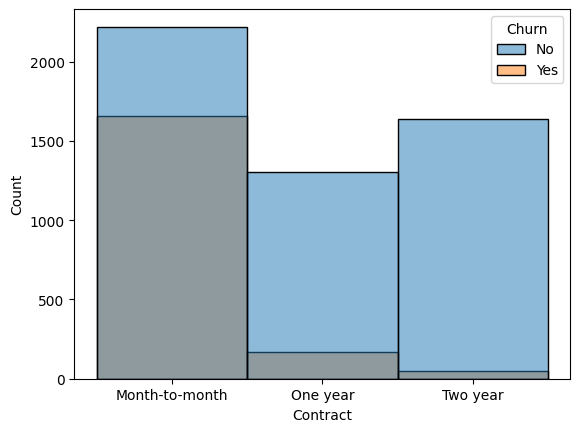

In [ ]:
sns.histplot(data=df,x='Contract',hue='Churn')

<Axes: xlabel='TotalCharges', ylabel='MonthlyCharges'>

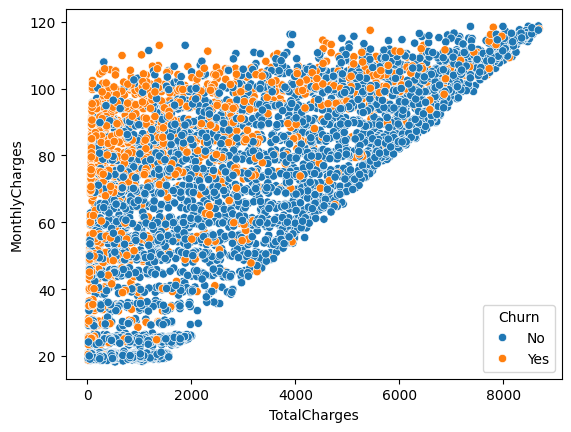

In [ ]:
sns.scatterplot(x='TotalCharges',y='MonthlyCharges',hue='Churn',data=df)

### Creating Cohorts based on Tenure

**Let's begin by treating each unique tenure length, 1 month, 2 month, 3 month...N months as its own cohort.**

In [ ]:
df['Churn']

,Churn
0,No
1,No
2,Yes
3,No
4,Yes
...,...
7027,No
7028,No
7029,No
7030,Yes


<Axes: xlabel='Churn', ylabel='tenure'>

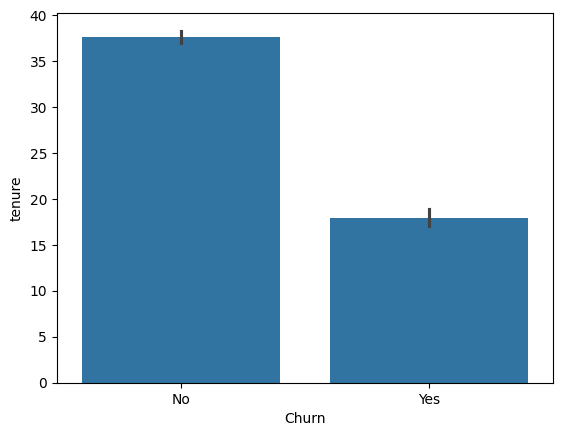

In [ ]:
sns.barplot(x='Churn',y='tenure',data=df)

In [ ]:
yes_churn=df.groupby(['Churn','tenure']).count().transpose()['Yes']
no_churn=df.groupby(['Churn','tenure']).count().transpose()['No']
percentage_churn=100*yes_churn/(yes_churn+no_churn)
percentage_churn.iloc[0]

,customerID
tenure,
1,61.990212
2,51.680672
3,47.000000
4,47.159091
5,48.120301
...,...
68,9.000000
69,8.421053
70,9.243697


In [ ]:
xyz=percentage_churn.transpose()['customerID']
xyz

,customerID
tenure,
1,61.990212
2,51.680672
3,47.000000
4,47.159091
5,48.120301
...,...
68,9.000000
69,8.421053
70,9.243697


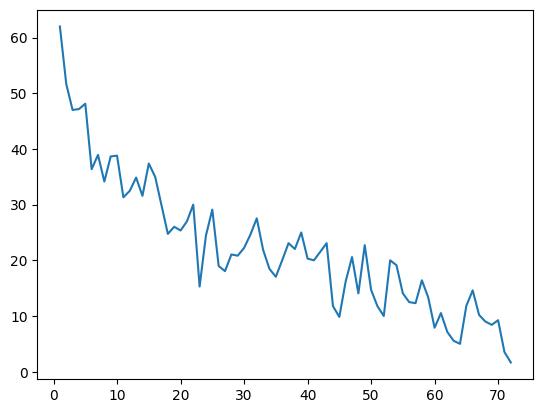

In [ ]:
plt.plot(xyz.index,xyz.values)

In [ ]:
def cohort(tenure):
    if tenure<13:
        return '0-12 Months'
    if tenure<25:
        return '12-24 Months'
    elif tenure<49:
        return '24-48 Months'
    else:
        return 'Over 48 Months'

In [ ]:
df['Tenure Cohort']=df['tenure'].apply(cohort)

In [ ]:
df['Tenure Cohort']

,Tenure Cohort
0,0-12 Months
1,24-48 Months
2,0-12 Months
3,24-48 Months
4,0-12 Months
...,...
7027,12-24 Months
7028,Over 48 Months
7029,0-12 Months
7030,0-12 Months


In [ ]:
df[['tenure','Tenure Cohort']]

,tenure,Tenure Cohort
0,1,0-12 Months
1,34,24-48 Months
2,2,0-12 Months
3,45,24-48 Months
4,2,0-12 Months
...,...,...
7027,24,12-24 Months
7028,72,Over 48 Months
7029,11,0-12 Months
7030,4,0-12 Months


<Axes: xlabel='TotalCharges', ylabel='MonthlyCharges'>

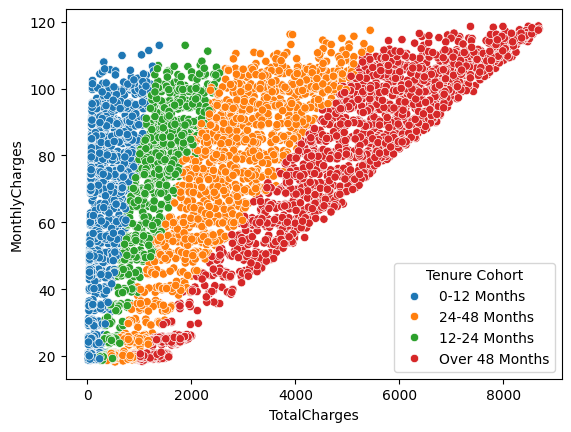

In [ ]:
sns.scatterplot(data=df,x='TotalCharges',y='MonthlyCharges',hue='Tenure Cohort')

<Axes: xlabel='Churn', ylabel='count'>

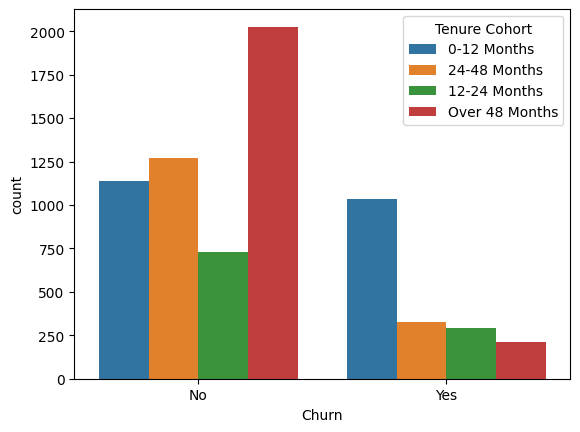

In [ ]:
sns.countplot(x='Churn',data=df,hue='Tenure Cohort')

<Axes: xlabel='Tenure Cohort', ylabel='count'>

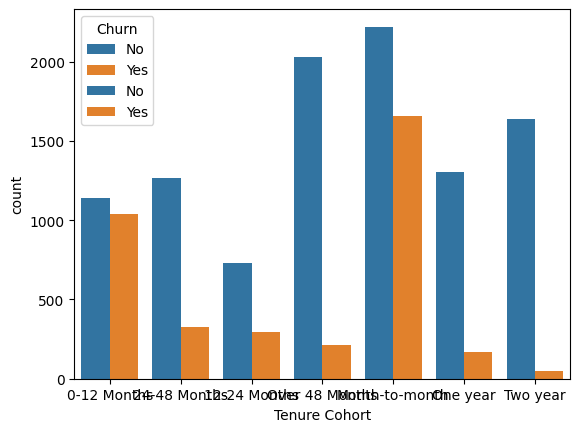

In [ ]:
sns.countplot(x='Tenure Cohort',hue='Churn',data=df)
sns.countplot(x='Contract',hue='Churn',data=df)

-----

# Part 4: Predictive Modeling



In [ ]:
pd.get_dummies(df)

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,customerID_0002-ORFBO,customerID_0003-MKNFE,customerID_0004-TLHLJ,customerID_0011-IGKFF,customerID_0013-EXCHZ,customerID_0013-MHZWF,...,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,Churn_No,Churn_Yes,Tenure Cohort_0-12 Months,Tenure Cohort_12-24 Months,Tenure Cohort_24-48 Months,Tenure Cohort_Over 48 Months
0,0,1,29.85,29.85,False,False,False,False,False,False,...,False,False,True,False,True,False,True,False,False,False
1,0,34,56.95,1889.50,False,False,False,False,False,False,...,False,False,False,True,True,False,False,False,True,False
2,0,2,53.85,108.15,False,False,False,False,False,False,...,False,False,False,True,False,True,True,False,False,False
3,0,45,42.30,1840.75,False,False,False,False,False,False,...,True,False,False,False,True,False,False,False,True,False
4,0,2,70.70,151.65,False,False,False,False,False,False,...,False,False,True,False,False,True,True,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7027,0,24,84.80,1990.50,False,False,False,False,False,False,...,False,False,False,True,True,False,False,True,False,False
7028,0,72,103.20,7362.90,False,False,False,False,False,False,...,False,True,False,False,True,False,False,False,False,True
7029,0,11,29.60,346.45,False,False,False,False,False,False,...,False,False,True,False,True,False,True,False,False,False
7030,1,4,74.40,306.60,False,False,False,False,False,False,...,False,False,False,True,False,True,True,False,False,False


In [ ]:
df['Churn'] = df['Churn'].map({'No': 0, 'Yes': 1})
X=df.drop(['customerID','Churn'],axis=1)
X=pd.get_dummies(X,drop_first=True)
X
y=df['Churn']

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=101)

In [ ]:
def solve(model,X_Train,y_Train,X_test,y_test):
    model.fit(X_Train,y_Train)
    pred = model.predict(X_test)
    print(classification_report(y_test,pred))
    print(model.best_params_)

In [ ]:
from sklearn.linear_model import LogisticRegression
model_lr = LogisticRegression(random_state=101,class_weight='balanced')

In [ ]:
param_grid = {'solver' : ['newton-cg','lbfgs'] , 'tol' : [0.001,0.005,0.01] , 'C' : [1,5,10]}
grid_lr = GridSearchCV(model_lr,param_grid,cv=5,scoring='recall')

In [ ]:
solve(grid_lr,X_train,y_train,X_test,y_test)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

              precision    recall  f1-score   support

           0       0.91      0.74      0.81      1052
           1       0.50      0.77      0.61       355

    accuracy                           0.75      1407
   macro avg       0.70      0.75      0.71      1407
weighted avg       0.80      0.75      0.76      1407

{'C': 1, 'solver': 'newton-cg', 'tol': 0.001}


In [ ]:
from sklearn.tree import DecisionTreeClassifier
model=DecisionTreeClassifier(class_weight='balanced',random_state=101)

In [ ]:
param_grid={'max_depth':[1,5,10],'criterion':['gini','log_loss','entropy']}
grid_dt=GridSearchCV(model,param_grid,scoring='recall')

In [ ]:
solve(grid_dt,X_train,y_train,X_test,y_test)

              precision    recall  f1-score   support

           0       0.97      0.33      0.49      1052
           1       0.33      0.97      0.49       355

    accuracy                           0.49      1407
   macro avg       0.65      0.65      0.49      1407
weighted avg       0.80      0.49      0.49      1407

{'criterion': 'gini', 'max_depth': 1}


In [ ]:
model.fit(X_train,y_train)
model.feature_importances_

array([0.01870519, 0.11153337, 0.15628083, 0.19013716, 0.02145842,
       0.01927084, 0.0179636 , 0.00668483, 0.00035692, 0.01250164,
       0.0390425 , 0.        , 0.        , 0.01963848, 0.00499158,
       0.01185417, 0.00059826, 0.01157746, 0.        , 0.01470698,
       0.        , 0.00926455, 0.        , 0.02024359, 0.09805127,
       0.15078152, 0.01677196, 0.0108654 , 0.02197554, 0.01166186,
       0.00134571, 0.00068339, 0.00105297])

In [ ]:
importance=pd.DataFrame(data=model.feature_importances_,index=X.columns,columns=['Feature Importance'])
imp=importance[importance['Feature Importance']>0]
imp

,Feature Importance
SeniorCitizen,0.018705
tenure,0.111533
MonthlyCharges,0.156281
TotalCharges,0.190137
gender_Male,0.021458
Partner_Yes,0.019271
Dependents_Yes,0.017964
PhoneService_Yes,0.006685
MultipleLines_No phone service,0.000357
MultipleLines_Yes,0.012502


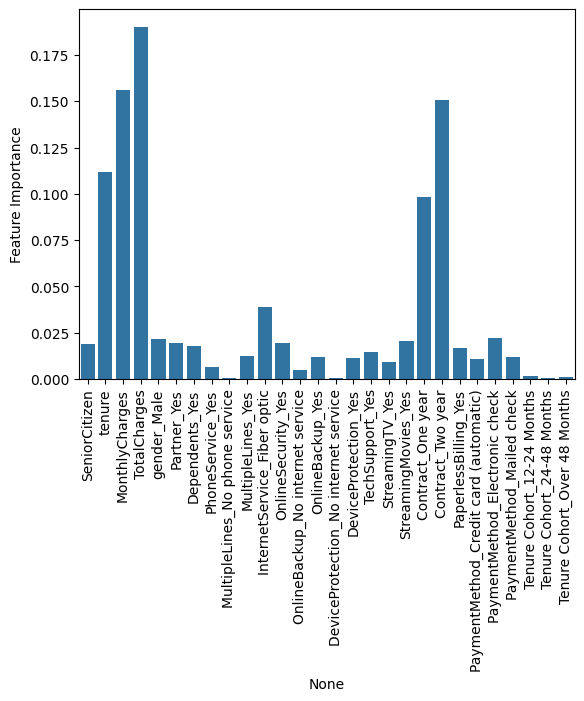

In [ ]:
sns.barplot(data=imp,y='Feature Importance',x=imp.index)
plt.xticks(rotation=90);

## Random Forest



In [ ]:
from sklearn.ensemble import RandomForestClassifier
model_rf=RandomForestClassifier(random_state=101,class_weight = 'balanced')

In [ ]:
param_grid = {'n_estimators' :  [1,5,10,100] , 'criterion' : ['gini','entropy','log_loss']}
grid_rf = GridSearchCV(model_rf,param_grid,scoring='recall')

In [ ]:
solve(grid_rf,X_train,y_train,X_test,y_test)

              precision    recall  f1-score   support

           0       0.84      0.86      0.85      1052
           1       0.55      0.50      0.52       355

    accuracy                           0.77      1407
   macro avg       0.69      0.68      0.69      1407
weighted avg       0.76      0.77      0.77      1407

{'criterion': 'entropy', 'n_estimators': 5}


## Boosted Trees

In [ ]:
from sklearn.ensemble import AdaBoostClassifier
model_adaboost=AdaBoostClassifier(random_state=101)

In [ ]:
param_grid = {'n_estimators' : [1,5,10,50,100] , 'learning_rate' : [1.0,5.0,10.0,100.0]}
grid_adaboost = GridSearchCV(model_adaboost,param_grid,scoring='recall')

In [ ]:
solve(grid_adaboost,X_train,y_train,X_test,y_test)

/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_weight_boosting.py:609: RuntimeWarning: overflow encountered in exp
  sample_weight = np.exp(
/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: UserWarning: Sample weights have reached infinite values, at iteration 1, causing overflow. Iterations stopped. Try lowering the learning rate.
  return fit_method(estimator, *args, **kwargs)
/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_weight_boosting.py:609: RuntimeWarning: overflow encountered in exp
  sample_weight = np.exp(
/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: UserWarning: Sample weights have reached infinite values, at iteration 1, causing overflow. Iterations stopped. Try lowering the learning rate.
  return fit_method(estimator, *args, **kwargs)
/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_weight_boosting.py:609: RuntimeWarning: overflow encountered in exp
  sample_weight = np.exp(
/usr/local/lib/python3.12/dist-packa

              precision    recall  f1-score   support

           0       1.00      0.00      0.00      1052
           1       0.25      1.00      0.40       355

    accuracy                           0.25      1407
   macro avg       0.63      0.50      0.20      1407
weighted avg       0.81      0.25      0.10      1407

{'learning_rate': 100.0, 'n_estimators': 5}


/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_weight_boosting.py:609: RuntimeWarning: overflow encountered in exp
  sample_weight = np.exp(
/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: UserWarning: Sample weights have reached infinite values, at iteration 1, causing overflow. Iterations stopped. Try lowering the learning rate.
  return fit_method(estimator, *args, **kwargs)
/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_weight_boosting.py:609: RuntimeWarning: overflow encountered in exp
  sample_weight = np.exp(
/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: UserWarning: Sample weights have reached infinite values, at iteration 1, causing overflow. Iterations stopped. Try lowering the learning rate.
  return fit_method(estimator, *args, **kwargs)
/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_weight_boosting.py:609: RuntimeWarning: overflow encountered in exp
  sample_weight = np.exp(
/usr/local/lib/python3.12/dist-packa

In [ ]:
from xgboost import XGBClassifier
model_xgboost = XGBClassifier(objective='binary:logistic',
    eval_metric='logloss',
    random_state=101)
param_grid = {
    'max_depth': [3, 4],
    'learning_rate': [0.1],
    'n_estimators': [100, 200],
    'subsample': [0.8],
    'colsample_bytree': [0.8],
    'scale_pos_weight': [1, 2]
}
grid_xgboost = GridSearchCV(model_xgboost,param_grid,cv=5,scoring='recall')

In [ ]:
solve(grid_xgboost,X_train,y_train,X_test,y_test)

              precision    recall  f1-score   support

           0       0.89      0.79      0.84      1052
           1       0.54      0.72      0.61       355

    accuracy                           0.77      1407
   macro avg       0.72      0.75      0.73      1407
weighted avg       0.80      0.77      0.78      1407

{'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100, 'scale_pos_weight': 2, 'subsample': 0.8}


In [ ]:
probs = grid_xgboost.predict_proba(X_test)[:,1]

thresholds = [0.50, 0.45, 0.40, 0.35]

for t in thresholds:
    preds = (probs >= t).astype(int)
    print("Threshold:", t)
    print(classification_report(y_test, preds))
    print("----------")

Threshold: 0.5
              precision    recall  f1-score   support

           0       0.89      0.79      0.84      1052
           1       0.54      0.72      0.61       355

    accuracy                           0.77      1407
   macro avg       0.72      0.75      0.73      1407
weighted avg       0.80      0.77      0.78      1407

----------
Threshold: 0.45
              precision    recall  f1-score   support

           0       0.91      0.76      0.83      1052
           1       0.52      0.77      0.62       355

    accuracy                           0.76      1407
   macro avg       0.71      0.76      0.72      1407
weighted avg       0.81      0.76      0.77      1407

----------
Threshold: 0.4
              precision    recall  f1-score   support

           0       0.92      0.71      0.80      1052
           1       0.49      0.81      0.61       355

    accuracy                           0.74      1407
   macro avg       0.70      0.76      0.70      1407
weight

###We performed probability threshold tuning to optimize the recall of the minority class (Churn = Yes). The optimal threshold was found to be 0.45, which increased churn recall from 0.71 → 0.77 while keeping the F1-score stable. This threshold offers the best balance between customer retention identification and false positive control.

In [ ]:
import shap
explainer = shap.TreeExplainer(grid_xgboost.best_estimator_)
shap_values = explainer.shap_values(X_test)

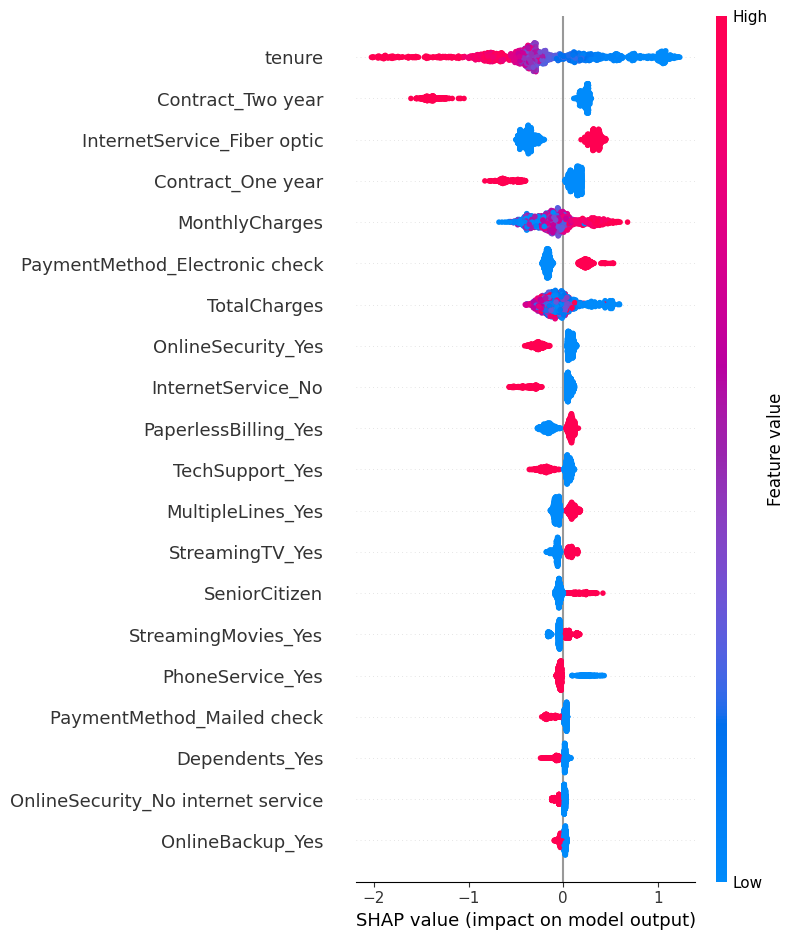

In [ ]:
shap.summary_plot(shap_values,X_test)

In [ ]:
shap.initjs()
shap.force_plot(explainer.expected_value, shap_values[10], X_test.iloc[10])

In [ ]:
log_odds = 1.09
pred = 1 / (1 + np.exp(-log_odds))
print(f"{pred.round(2) * 100} % likely to churn")

75.0 % likely to churn


In [ ]:
grid_xgboost.best_estimator_.predict_proba(X_test.iloc[[10]])

array([[0.25126672, 0.7487333 ]], dtype=float32)

In [ ]:
import joblib
import json
model = joblib.dump(grid_xgboost.best_estimator_,"model.pkl")
with open("columns.json" , "w") as f:
  json.dump(list(X.columns),f)

In [ ]:
import gradio as gr
import pandas as pd
import numpy as np
import joblib, json
import shap
import matplotlib.pyplot as plt


model = joblib.load("model.pkl")

with open("columns.json", "r") as f:
    MODEL_COLUMNS = json.load(f)

explainer = shap.Explainer(model)


def preprocess_input(gender, senior, partner, dependents, tenure,
                     phone, multiple, internet, online_sec, online_backup,
                     device_protect, tech_support, stream_tv, stream_movie,
                     contract, paperless, payment, monthly, total):

    df = pd.DataFrame([[gender, senior, partner, dependents, tenure,
                        phone, multiple, internet, online_sec, online_backup,
                        device_protect, tech_support, stream_tv, stream_movie,
                        contract, paperless, payment, monthly, total]],
                      columns=['gender','SeniorCitizen','Partner','Dependents','tenure',
                               'PhoneService','MultipleLines','InternetService','OnlineSecurity','OnlineBackup',
                               'DeviceProtection','TechSupport','StreamingTV','StreamingMovies',
                               'Contract','PaperlessBilling','PaymentMethod','MonthlyCharges','TotalCharges'])

    df = pd.get_dummies(df, drop_first=True)

    for col in MODEL_COLUMNS:
        if col not in df:
            df[col] = 0

    df = df[MODEL_COLUMNS]
    return df


THRESHOLD = 0.45

def predict_and_shap(gender, senior, partner, dependents, tenure,
                     phone, multiple, internet, online_sec, online_backup,
                     device_protect, tech_support, stream_tv, stream_movie,
                     contract, paperless, payment, monthly, total):

    X = preprocess_input(gender, senior, partner, dependents, tenure,
                         phone, multiple, internet, online_sec, online_backup,
                         device_protect, tech_support, stream_tv, stream_movie,
                         contract, paperless, payment, monthly, total)


    prob = float(model.predict_proba(X)[0][1])
    pred = "Yes (Likely to Churn)" if prob >= THRESHOLD else "No (Not Likely)"

    result = {
        "Churn Probability (%)": round(prob * 100, 2),
        "Prediction": pred
    }

    explainer = shap.TreeExplainer(model.get_booster())
    shap_values = explainer(X)
    base_value = explainer.expected_value
    values = shap_values[0].values

    plt.figure(figsize=(8, 4))
    shap.summary_plot(shap_values, X, show=False)
    plt.savefig("summary_local.png", dpi=120, bbox_inches="tight")
    plt.close()

    plt.figure(figsize=(10, 3))
    shap.force_plot(
        base_value,
        values,
        X.iloc[0],
        matplotlib=True,
        show=False
    )
    plt.savefig("force_local.png", dpi=120, bbox_inches='tight')
    plt.close()

    return result, "summary_local.png", "force_local.png"


inputs = [
    gr.Dropdown(["Male","Female"], label="Gender"),
    gr.Dropdown([0,1], label="Senior Citizen"),
    gr.Dropdown(["Yes","No"], label="Partner"),
    gr.Dropdown(["Yes","No"], label="Dependents"),
    gr.Slider(0,72,step=1,label="Tenure (months)"),
    gr.Dropdown(["Yes","No"], label="Phone Service"),
    gr.Dropdown(["Yes","No"], label="Multiple Lines"),
    gr.Dropdown(["DSL","Fiber optic","No"], label="Internet Service"),
    gr.Dropdown(["Yes","No"], label="Online Security"),
    gr.Dropdown(["Yes","No"], label="Online Backup"),
    gr.Dropdown(["Yes","No"], label="Device Protection"),
    gr.Dropdown(["Yes","No"], label="Tech Support"),
    gr.Dropdown(["Yes","No"], label="Streaming TV"),
    gr.Dropdown(["Yes","No"], label="Streaming Movies"),
    gr.Dropdown(["Month-to-month","One year","Two year"], label="Contract"),
    gr.Dropdown(["Yes","No"], label="Paperless Billing"),
    gr.Dropdown(["Electronic check","Mailed check","Bank transfer (automatic)","Credit card (automatic)"], label="Payment Method"),
    gr.Number(label="Monthly Charges"),
    gr.Number(label="Total Charges")
]

outputs = [
    gr.JSON(label="Prediction"),
    gr.Image(type="filepath", label="Local SHAP Summary Plot"),
    gr.Image(type="filepath", label="Local SHAP Force Plot")
]

gr.Interface(
    fn=predict_and_shap,
    inputs=inputs,
    outputs=outputs,
    title="Telco Churn Prediction with Local SHAP",
    description="Predict churn and view SHAP summary + force plot for this user's input only."
).launch()


It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://e9fee3496265330d0f.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [ ]:
%%writefile app.py
import gradio as gr
import pandas as pd
import numpy as np
import joblib, json
import shap
import matplotlib.pyplot as plt



model = joblib.load("model.pkl")

with open("columns.json", "r") as f:
    MODEL_COLUMNS = json.load(f)

def preprocess_input(gender, senior, partner, dependents, tenure,
                     phone, multiple, internet, online_sec, online_backup,
                     device_protect, tech_support, stream_tv, stream_movie,
                     contract, paperless, payment, monthly, total):

    df = pd.DataFrame([[gender, senior, partner, dependents, tenure,
                        phone, multiple, internet, online_sec, online_backup,
                        device_protect, tech_support, stream_tv, stream_movie,
                        contract, paperless, payment, monthly, total]],
                      columns=['gender','SeniorCitizen','Partner','Dependents','tenure',
                               'PhoneService','MultipleLines','InternetService','OnlineSecurity','OnlineBackup',
                               'DeviceProtection','TechSupport','StreamingTV','StreamingMovies',
                               'Contract','PaperlessBilling','PaymentMethod','MonthlyCharges','TotalCharges'])


    df = pd.get_dummies(df, drop_first=True)


    for col in MODEL_COLUMNS:
        if col not in df:
            df[col] = 0


    df = df[MODEL_COLUMNS]
    return df


THRESHOLD = 0.45


def predict_and_shap(gender, senior, partner, dependents, tenure,
                     phone, multiple, internet, online_sec, online_backup,
                     device_protect, tech_support, stream_tv, stream_movie,
                     contract, paperless, payment, monthly, total):


    X = preprocess_input(gender, senior, partner, dependents, tenure,
                         phone, multiple, internet, online_sec, online_backup,
                         device_protect, tech_support, stream_tv, stream_movie,
                         contract, paperless, payment, monthly, total)


    prob = float(model.predict_proba(X)[0][1])
    pred = "Yes (Likely to Churn)" if prob >= THRESHOLD else "No (Not Likely)"

    result = {
        "Churn Probability (%)": round(prob * 100, 2),
        "Prediction": pred
    }

    return result



inputs = [
    gr.Dropdown(["Male","Female"], label="Gender"),
    gr.Dropdown([0,1], label="Senior Citizen"),
    gr.Dropdown(["Yes","No"], label="Partner"),
    gr.Dropdown(["Yes","No"], label="Dependents"),
    gr.Slider(0,72,step=1,label="Tenure (months)"),
    gr.Dropdown(["Yes","No"], label="Phone Service"),
    gr.Dropdown(["Yes","No"], label="Multiple Lines"),
    gr.Dropdown(["DSL","Fiber optic","No"], label="Internet Service"),
    gr.Dropdown(["Yes","No"], label="Online Security"),
    gr.Dropdown(["Yes","No"], label="Online Backup"),
    gr.Dropdown(["Yes","No"], label="Device Protection"),
    gr.Dropdown(["Yes","No"], label="Tech Support"),
    gr.Dropdown(["Yes","No"], label="Streaming TV"),
    gr.Dropdown(["Yes","No"], label="Streaming Movies"),
    gr.Dropdown(["Month-to-month","One year","Two year"], label="Contract"),
    gr.Dropdown(["Yes","No"], label="Paperless Billing"),
    gr.Dropdown(["Electronic check","Mailed check","Bank transfer (automatic)","Credit card (automatic)"], label="Payment Method"),
    gr.Number(label="Monthly Charges"),
    gr.Number(label="Total Charges")
]

outputs = [
    gr.JSON(label="Prediction")
]

gr.Interface(
    fn=predict_and_shap,
    inputs=inputs,
    outputs=outputs,
    title="Telco Churn Prediction with Local SHAP Explainability",
    description="Enter customer details to predict churn and view SHAP explanations."
).launch()


Overwriting app.py


In [ ]:
%%writefile requirements.txt
gradio==4.19.2
pandas
numpy
scikit-learn
xgboost
joblib
shap
matplotlib

Overwriting requirements.txt


# 📞 Telco Customer Churn Prediction (XGBoost + SHAP)

A machine learning project that predicts whether a telecom customer will **churn** and explains **why** using SHAP values. The model is deployed using a simple Gradio interface.

---

## 🚀 Features
- **XGBoost model** trained with class balancing and hyperparameter tuning  
- **Threshold tuning** (0.45) to improve churn recall  
- **Local SHAP explainability** for each user:
  - SHAP summary plot  
  - SHAP force plot  

---

## 🧠 Tech Stack
Python, Pandas, NumPy, Scikit-learn, XGBoost, SHAP, Gradio, Hugging Face Spaces

---

## 🧪 Model Performance
After tuning:
- Precision (Churn): ~0.54  
- Recall (Churn): ~0.71  
- F1 Score (Churn): ~0.61  

Optimized to detect customers at high risk of churn.

---

## 🖥 Deployment
The app takes customer inputs → predicts churn probability → shows SHAP explanations for that user.

**Files included:**
- `app.py` (Gradio app)  
- `model.pkl` (trained model)  
- `columns.json` (training feature order)  
- `requirements.txt`  

In [ ]:
# With base models, we got best performance from an AdaBoostClassifier, but note, we didn't do any gridsearching AND most models performed about the same on the data set.